# WORK IN PROGRESS

In [2]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries
from general_utils.regression import choose_CV_type, evaluate_prediction

In [26]:
from sklearn.linear_model import LinearRegression, RidgeCV, MultiTaskLassoCV, MultiTaskElasticNetCV

def choose_regression_type(regression_type='lr', alphas=np.logspace(-6, 3, 10)):
    if regression_type == 'lr': 
        regression_obj = LinearRegression()
    elif regression_type == 'ridge': 
        regression_obj = RidgeCV(alphas=alphas)
    elif regression_type == 'lasso': 
        regression_obj = MultiTaskLassoCV(alphas=alphas, max_iter=10000)
    elif regression_type == 'en': 
        regression_obj = MultiTaskElasticNetCV(alphas=alphas, max_iter=10000, l1_ratio=[0.1, 0.5, 0.9])
    else:
        raise ValueError("regression_type must be 'lr', 'ridge', 'lasso', 'en'")
    return regression_obj
# EOF

alphas = np.logspace(-6, 3, 10)

In [27]:
def static_lagged_linear_regression(x, y, regression_type='lr', alphas=np.logspace(-6, 3, 10), cv_type='same', n_splits=5, shuffle=True):
    lr_list = []
    x_shifted_tot = x.T
    for tau in range(y.shape[1]):
        y_shifted_tot = y[:,tau,:].T
        CV = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
        curr_lr = []
        for train_idx, test_idx in CV.split(x_shifted_tot):
            train_x, train_y = x_shifted_tot[train_idx, :], y_shifted_tot[train_idx, :]
            test_x, test_y = x_shifted_tot[test_idx, :], y_shifted_tot[test_idx, :]
            regression_obj = choose_regression_type(regression_type=regression_type, alphas=alphas)
            regression_obj = regression_obj.fit(train_x, train_y)
            avg_corr = evaluate_prediction(test_x, test_y, regression_obj)
            curr_lr.append(avg_corr)
        # end for train_idx, test_idx in CV.split(x_shifted_tot):
        lr_list.append(np.nanmean(curr_lr))  #x_t_shifted_tot, y_t_shifted_tot))
    # end for L in range(-max_lag, max_lag):    
    return lr_list
# EOF


In [5]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul' 
    date: str = '230204'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    RDM_metric_A: str = 'cosine'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()

### load brain data and model

In [6]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [ ]:
ba_obj = BrainAreas(cfg.monkey_name)
ba_raster = ba_obj.slice_brain_area(raster, cfg.brain_area)

In [8]:
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; layer_name = 'blocks.1.mlp.fc2'

feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]

keep only the first 1000 images to speed up the analyses

In [9]:
try_raster = TimeSeries(ba_raster.get_array()[:,:,:1000], raster.get_fs()) 
feats = features[:,:1000] 

In [10]:
lr_list = static_lagged_linear_regression(feats, ba_raster.get_array(), regression_type='lr', alphas=np.logspace(-6, 3, 10), cv_type='kf')

Text(0.5, 1.0, 'normal linear regression')

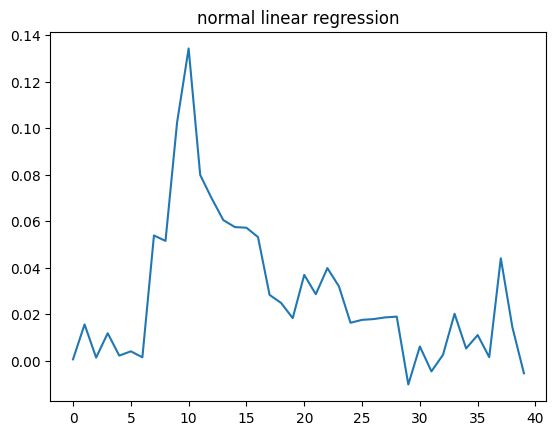

In [12]:
plt.plot(lr_list)
plt.title("normal linear regression")

In [28]:
lr_list = static_lagged_linear_regression(feats, ba_raster.get_array(), regression_type='en', alphas=np.logspace(-6, 3, 10), cv_type='kf')

/Users/tizianocausin/Desktop/virtual_envs/temporal_context/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:673: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.714e+01, tolerance: 4.070e-02
  model = cd_fast.enet_coordinate_descent_multi_task(


KeyboardInterrupt: 

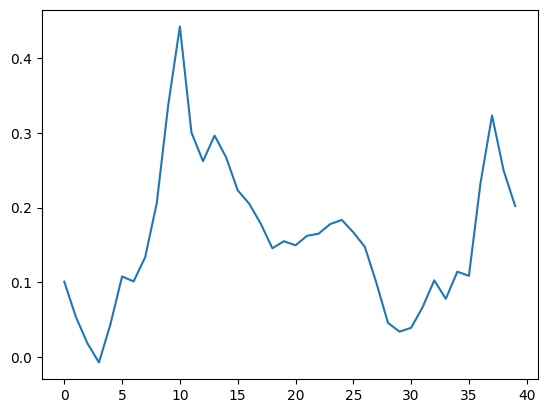

In [ ]:
plt.plot(lr_list)